In [1]:
import os
import pandas as pd
import numpy as np
from ast import literal_eval
import re
from database import LoadAllUsers

import os
import csv
from openpyxl import Workbook


In [13]:
import pandas as pd

# Sample DataFrame
data = {'A': [4, 6, 7, 2, 8],
        'B': [3, 9, 2, 6, 1],
        'C': [0, 2, 3, 4, 5]}

df = pd.DataFrame(data)

# User-provided condition text
user_condition_text = "condition_A & condition_B | condition_C"

# Define conditions based on user input
condition_A = df['A'] > 5
condition_B = df['B'] > 2
condition_C = df['C'] < 3

# Use the eval function to evaluate the user-provided condition text
filtered_df = df[eval(user_condition_text)]

print(filtered_df)


SyntaxError: EOL while scanning string literal (<string>, line 1)

In [37]:

maxUser = 51
df = LoadAllUsers(maxUser, None)

# maxUser = 3
# path = 'C:/Users/z5308/Desktop/VRTestingProject/data/small/'
# df = LoadAllUsers(maxUser, path)





Openning user0-turn0-lvl11.csv
Openning user0-turn1-lvl4.csv
Openning user0-turn2-lvl14.csv
Openning user0-turn3-lvl0.csv
Openning user0-turn4-lvl2.csv
Openning user0-turn5-lvl7.csv
Openning user0-turn6-lvl7.csv
Openning user0-turn7-lvl1.csv
Openning user0-turn8-lvl8.csv
Openning user0-turn9-lvl13.csv
Openning user0-turn10-lvl12.csv
Openning user0-turn11-lvl6.csv
Openning user0-turn12-lvl3.csv
Openning user0-turn13-lvl15.csv
Openning user0-turn14-lvl10.csv
Openning user0-turn15-lvl5.csv
Openning user0-turn16-lvl9.csv
Openning user1-turn0-lvl14.csv
Openning user1-turn1-lvl9.csv
Openning user1-turn2-lvl12.csv
Openning user1-turn3-lvl1.csv
Openning user1-turn4-lvl13.csv
Openning user1-turn5-lvl4.csv
Openning user1-turn6-lvl2.csv
Openning user1-turn7-lvl3.csv
Openning user1-turn8-lvl0.csv
Openning user1-turn9-lvl5.csv
Openning user1-turn10-lvl10.csv
Openning user1-turn11-lvl7.csv
Openning user1-turn12-lvl11.csv
Openning user1-turn13-lvl8.csv
Openning user1-turn14-lvl15.csv
Openning user1-t

In [23]:
import pandas as pd

# Sample DataFrame
data = {'A': [4, 6, 7, 2, 8],
        'B': [3, 9, 2, 6, 1],
        'C': [0, 2, 3, 4, 5]}

df = pd.DataFrame(data)

# User-provided condition text
user_input = "Condition A & Condition B | Condition C"


# Use the query method to filter the DataFrame
filtered_df = df.query("A > 5 and (B > 5 or C > 1)")
filtered_df = df.query("B > 5 or C > 1 and A > 5")
print(filtered_df)


   A  B  C
1  6  9  2
2  7  2  3
3  2  6  4
4  8  1  5


In [ ]:
df['UserRecord'] =  "user"+df['userID'].astype(str) + '_'+"turn" + df['turn'].astype(str)

users_to_plot = ['user1_', 'user5_', 'user9_']
filtered_data =  df[df['UserRecord'].apply(lambda x: any(x.startswith(prefix) for prefix in users_to_plot))]

filtered_data

In [65]:
import pandas as pd
import matplotlib.pyplot as plt

#user_records_to_plot_corrected = ["user5_turn11", "user9_turn14", "user1_turn8", "user1_turn17"]
# os.chdir('C:/Users/z5308/Desktop/VRTestingProject/data/spreedsheet/forGPT/')

# walking_data = pd.read_csv('./PosData_Level0.csv')

# walking_data= pd.read_csv('./PosData_Level0.csv')
# # Extract the walking paths for user 1, 5, and 9
# user_ids = ['user1', 'user5', 'user9']
# walking_paths = {user_id: [] for user_id in user_ids}

# # Iterate through each column (user record)
# for column in walking_data.columns:
#     user_id = column.split('_')[0]
#     if user_id in user_ids:
#         # Extract the x and y coordinates
#         positions = walking_data[column].dropna().str.strip('[]').str.split(', ', expand=True)
#         positions.columns = ['x', 'y']
#         positions = positions.astype(float)
#         walking_paths[user_id].append(positions)

# # Plotting the walking paths
# plt.figure(figsize=(12, 8))
# for user_id, paths in walking_paths.items():
#     for path in paths:
#         plt.plot(path['x'], path['y'], label=f'{user_id} path')

# plt.title('Walking Paths of Users 1, 5, and 9')
# plt.xlabel('X Coordinate')
# plt.ylabel('Y Coordinate')
# plt.legend()
# plt.grid(True)
# plt.show()


os.chdir('C:/Users/z5308/Desktop/VRTestingProject/data/spreedsheet/forGPT/')
# Loading the discrete data
discrete_data = pd.read_csv('./DiscreteData_Level0.csv')


# Extracting unique user records
unique_users = discrete_data['UserRecord'].str.extract(r'(user\d+)')[0].unique()

# Initializing groups
group1, group2, group3 = [], [], []

# Classifying each user based on their gameplay record and subjective ratings
for user in unique_users:
    user_records = discrete_data[discrete_data['UserRecord'].str.contains(user)]

    # Averaging the ratings and results for each user
    avg_gameplay_result = user_records['GameplayResult'].mean()
    avg_difficulty_rating = user_records['DifficultyRating'].mean()
    avg_scariness_rating = user_records['ScarinessRating'].mean()

    # Criteria for Group 1
    if avg_gameplay_result > 0 and avg_difficulty_rating < 5 and avg_scariness_rating < 5:
        group1.append(user)
    # Criteria for Group 2
    elif avg_gameplay_result < 0 and (avg_difficulty_rating >= 5 or avg_scariness_rating >= 5):
        group2.append(user)
    # Criteria for Group 3
    else:
        group3.append(user)

# Preparing the classification table
classification_table = {
    "Group 1": group1,
    "Group 2": group2,
    "Group 3": group3
}

classification_table['Group 1'][:5]
classification_table['Group 2'][:5]
classification_table['Group 3'][:5]

['user7', 'user14', 'user16', 'user17', 'user21']

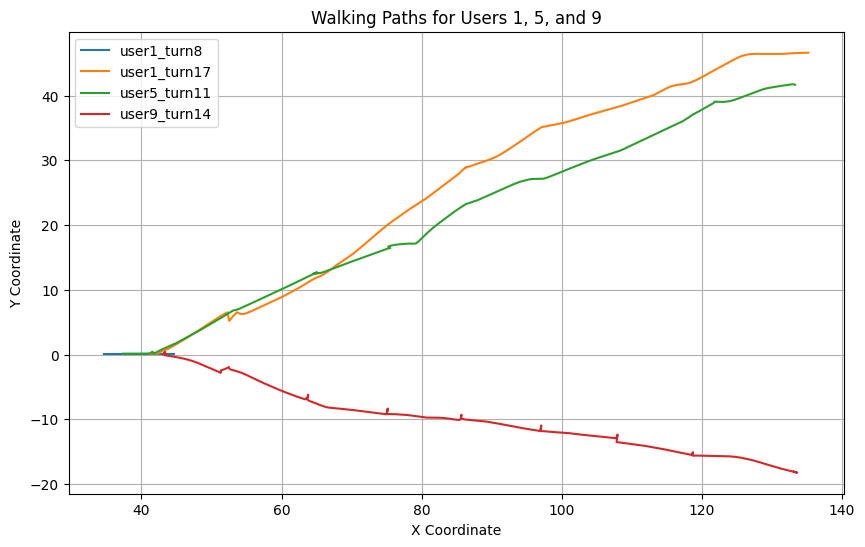

In [53]:
import matplotlib.pyplot as plt


filtered_data = pd.read_csv('./PosData_Level0.csv')
# Extract and plot the walking paths for users 1, 5, and 9
def plot_user_walk(user_data, user_id):
    # Extracting x and y coordinates
    x_coords = []
    y_coords = []
    for position in user_data.dropna():
        x, y = eval(position)
        x_coords.append(x)
        y_coords.append(y)
    
    # Plotting the walking path
    plt.plot(x_coords, y_coords, label=f'{user_id}')

# Plotting for each user
plt.figure(figsize=(10, 6))
user_ids = [1,5,9] # ["user1","user5","user9"]
for user_id in user_ids:
    # Extract all columns for the user
    user_columns = filtered_data.filter(regex=f'user{user_id}_turn')
   
    # Plot each turn for the user
    for column in user_columns:
        plot_user_walk(user_columns[column], column)

plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.title('Walking Paths for Users 1, 5, and 9')
plt.legend()
plt.grid(True)
plt.show()

In [43]:
def outputSelectedLevel(level):
    df2 = df[(df['levelDiff'] == level)]

   
    filter_df = df2[['UserRecord',  'DifficultyRating', 'ScarinessRating', 'FunRating',
                'GameplayResult','GameplayDur']]
    os.chdir('C:/Users/z5308/Desktop/VRTestingProject/data/spreedsheet/forGPT/')
    csv_file_path = f'../level{level}.csv'

    # Export the DataFrame to a CSV file
    filter_df.to_csv(csv_file_path, index=False)  # Set index=False to exclude row numbers in the CSV

    return filter_df

def outputPosRot(level, colName = "Pos"):
    df2 = df[(df['levelDiff'] == level)]

    filter_df = df2[['userID', 'turn',  'plyr_pos', 'plyr_rot']]

    x_names = [ f"user{x}_turn{y}"  for x, y in zip(filter_df['userID'], filter_df['turn'] )]

    x_col = None
    if(colName == "Pos"):
        x_col = 'plyr_pos'
    else:
        x_col = 'plyr_rot'


    data = {}
    num_rows = df.shape[0]

    for x, y, z in zip(filter_df['userID'], filter_df['turn'] , filter_df[x_col]):
        finalLoc = []
        if(colName == "Pos"):
            finalLoc = [    [loc[0],loc[2]]   for loc in z]
        else:
            finalLoc = [   loc[1]   for loc in z]
        #print(finalLoc[:4])
        data [ f"user{x}_turn{y}" ] = finalLoc

    #Find the maximum length among the arrays:   
    max_length = max(len(items) for items in data.values())  

    os.chdir('C:/Users/z5308/Desktop/VRTestingProject/data/spreedsheet/forGPT/')
    csv_file_path = f'./{colName}Data_Level{level}.csv'
    # Open a file for writing
    with open(csv_file_path, 'w', newline='') as file:
        writer = csv.writer(file)

        # Write the header
        writer.writerow(data.keys())

        # Write the data rows
        for i in range(max_length):
            row = [data[key][i] if i < len(data[key]) else None for key in data]
            writer.writerow(row)
    #     #print(new_df)
    # os.chdir('C:/Users/z5308/Desktop/VRTestingProject/data/spreedsheet/forGPT/')
    # csv_file_path = f'./{colName}Data_Level{level}.csv'
    # finaldf.to_csv(csv_file_path, index=False)  # Set index=False to exclude row numbers in the CSV
for i in range(0, 1):
    outputSelectedLevel(i)
    
    #outputPosRot(i, colName= "Rot")
    #outputPosRot(i, colName= "Pos")

In [ ]:


def split(file):
    file_parts = file.split(".")
    id = int(re.search(r'\d+', file_parts[0]).group()) 
    return id

def castFloat(v):
    r = v
    try:
        r = float(v)
    except:
        ...
    return r

def CreateExcel(fileStartWith = "level", outputName = "allCSV" ):
    # Create a new workbook
    os.chdir('C:/Users/z5308/Desktop/VRTestingProject/data/spreedsheet/csv/')

    wb = Workbook()
    df2 = df[['userID', 'turn',  'DifficultyRating', 'ScarinessRating', 'FunRating',
                'GameplayResult','GameplayDur']]

    csv_file_path = f'all.csv'
    df2.to_csv(csv_file_path, index=False)


    #create worksheet that store all data
    ws = wb.create_sheet("AllData")
    with open('all.csv') as csv_file:
        # Read CSV file into a list of rows
        rows = list(csv.reader(csv_file))
        for row in rows:
            
            f_row = [castFloat(val)  for val in row]  
                
            #f_row = [float(val) if(isinstance(val, float)) else val for val in row]  
           
            ws.append(f_row)

    # filename = f"../test.xlsx"
    # wb.save(filename)


    
    # # # Get list of CSV files in current directory
    csv_files = [f for f in os.listdir('./') if (f.endswith('.csv') and f.startswith(fileStartWith))]
    csv_files.sort(key = lambda x: split(x))

   

    # create a worksheet for each csv file
    for f in csv_files:
        print(f"openning {f}")
        # Open CSV file
        with open(f) as csv_file:
            # Read CSV file into a list of rows
            rows = list(csv.reader(csv_file))
            
        # Get worksheet by CSV filename 
        ws = wb.create_sheet(os.path.splitext(f)[0])  
        
        # header_row = True

        # # Write rows to worksheet  
        # for row in rows:
        #     if header_row:
        #         header_row = False
        #         ws.append(row)
        #         continue

        #     row = [float(val) for val in row]  
        #     ws.append(row)
            

        # Write rows to worksheet  
        for row in rows:
           
            row = [castFloat(val) for val in row]  
            ws.append(row)
            
    # # # Save workbook 
    filename = f"../{outputName}.xlsx"
    wb.save(filename)
    
CreateExcel()
#CreateExcel(fileStartWith="PosData", outputName= "PosData")
#CreateExcel(fileStartWith="RotData", outputName= "RotData")

In [ ]:
isinstance("5.0", float)